"멀리 배송해도 고객이 욕 안 하고 만족하는 놈이 누구냐?" (절대값 필터링을 빼고, 장거리 배송 중 평점 1~10위를 뽑는 방식으로 변경)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

In [2]:
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
BASE_PATH = r'D:\AiSon\DTS\BDW'

In [4]:
# 1. 데이터 로드
orders = pd.read_csv(os.path.join(BASE_PATH, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_items_dataset.csv'))
customers = pd.read_csv(os.path.join(BASE_PATH, 'olist_customers_dataset.csv'))
sellers = pd.read_csv(os.path.join(BASE_PATH, 'olist_sellers_dataset.csv'))
reviews = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_reviews_dataset.csv'))
geo = pd.read_csv(os.path.join(BASE_PATH, 'olist_geolocation_dataset.csv'))
products = pd.read_csv(os.path.join(BASE_PATH, 'olist_products_dataset.csv'))
trans = pd.read_csv(os.path.join(BASE_PATH, 'product_category_name_translation.csv'))

In [5]:
# 2. 병합 및 거리 계산
df = orders.merge(items, on='order_id')
df = df.merge(customers[['customer_id', 'customer_zip_code_prefix']], on='customer_id')
df = df.merge(sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id')
products = products.merge(trans, on='product_category_name', how='left')
df = df.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')

In [6]:
geo_avg = geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()
df = df.merge(geo_avg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 'c_lat', 'geolocation_lng': 'c_lng'})
df = df.merge(geo_avg, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 's_lat', 'geolocation_lng': 's_lng'})

R = 6371
phi1, phi2 = np.radians(df['c_lat']), np.radians(df['s_lat'])
dphi = np.radians(df['s_lat'] - df['c_lat'])
dlambda = np.radians(df['s_lng'] - df['c_lng'])
a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2) * np.sin(dlambda/2)**2
df['distance_km'] = R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

In [7]:
# 3. [핵심] Hero 추출 로직 (Rank 방식)
stats = df.groupby('product_category_name_english').agg({
    'order_id': 'count',
    'review_score': 'mean',
    'distance_km': 'mean',
    'price': 'mean'
}).reset_index()
stats.columns = ['Category', 'Volume', 'Score', 'Distance', 'Price']

In [8]:
# 조건: 거리가 전체 평균보다 먼 것들 중에서
long_dist_items = stats[stats['Distance'] > stats['Distance'].mean()]

In [9]:
# 무조건 평점 높은 순으로 10개 자름 (Empty 방지)
hero_top10 = long_dist_items.sort_values(by='Score', ascending=False).head(10)

print("\n" + "="*60)
print("🚀 [전략 1 결과] Hero Item (장거리 고만족 TOP 10)")
print("="*60)
print(hero_top10[['Category', 'Score', 'Distance', 'Volume']].to_string(index=False))


🚀 [전략 1 결과] Hero Item (장거리 고만족 TOP 10)
                 Category    Score    Distance  Volume
fashion_childrens_clothes 4.500000  591.536197       8
  costruction_tools_tools 4.444444  597.382064      99
            fashion_shoes 4.230769  733.921128     260
            fashion_sport 4.206897  718.945666      29
                computers 4.170854 1061.608827     199
        home_appliances_2 4.151899  595.508023     237
      musical_instruments 4.151335  647.124003     674
               cool_stuff 4.147264  653.548196    3728
 fashion_bags_accessories 4.144756  594.321826    2031
            health_beauty 4.142575  664.994165    9616


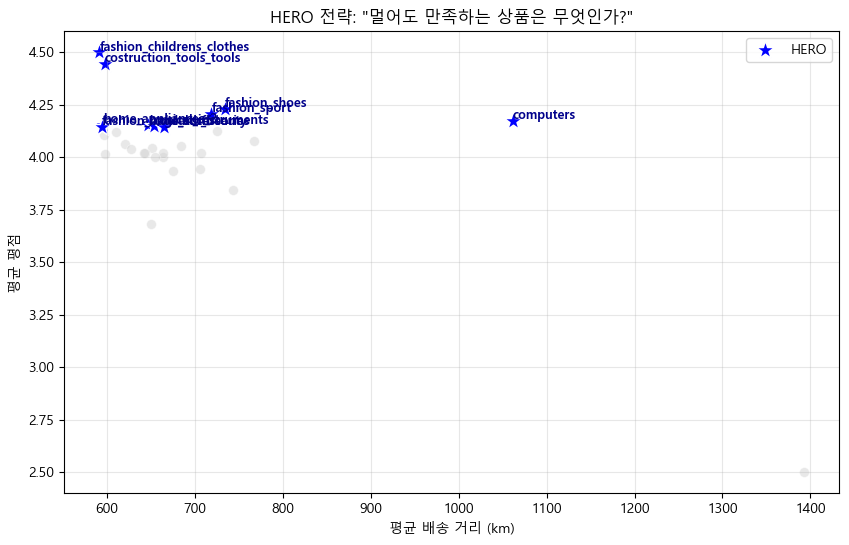

In [10]:
# 4. 시각화 (이름표 필수)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=long_dist_items, x='Distance', y='Score', color='lightgray', s=50, alpha=0.5)
sns.scatterplot(data=hero_top10, x='Distance', y='Score', color='blue', s=200, marker='*', label='HERO')

for i in range(len(hero_top10)):
    row = hero_top10.iloc[i]
    plt.text(row['Distance'], row['Score']+0.01, row['Category'], fontsize=9, fontweight='bold', color='darkblue')

plt.title('HERO 전략: "멀어도 만족하는 상품은 무엇인가?"')
plt.xlabel('평균 배송 거리 (km)')
plt.ylabel('평균 평점')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
#Cash Cow 추출 로직 (Rank 방식)
# 조건: 거리가 전체 평균보다 가까운 것들 중에서 (근거리 시장)
short_dist_items = stats[stats['Distance'] < stats['Distance'].mean()]

In [17]:
# 무조건 '주문량(Volume)' 많은 순으로 10개 자름 (절대 빈 표 안 나옴)
cash_cow_top10 = short_dist_items.sort_values(by='Volume', ascending=False).head(10)
print("\n" + "="*60)
print("💰 [전략 2 결과] Cash Cow (근거리 고매출 TOP 10)")
print("="*60)
print(cash_cow_top10[['Category', 'Volume', 'Score', 'Distance']].to_string(index=False))


💰 [전략 2 결과] Cash Cow (근거리 고매출 TOP 10)
                       Category  Volume    Score   Distance
                 bed_bath_table   11109 3.896030 509.666243
                furniture_decor    8311 3.902539 561.770190
                     housewares    6924 4.055604 495.373214
                           toys    4055 4.161282 561.750070
                      perfumery    3406 4.160599 572.258531
                     stationery    2491 4.193497 560.542809
                       pet_shop    1918 4.181439 552.460779
               office_furniture    1681 3.492564 555.857030
            luggage_accessories    1084 4.314576 556.474423
construction_tools_construction     919 4.062024 521.134262


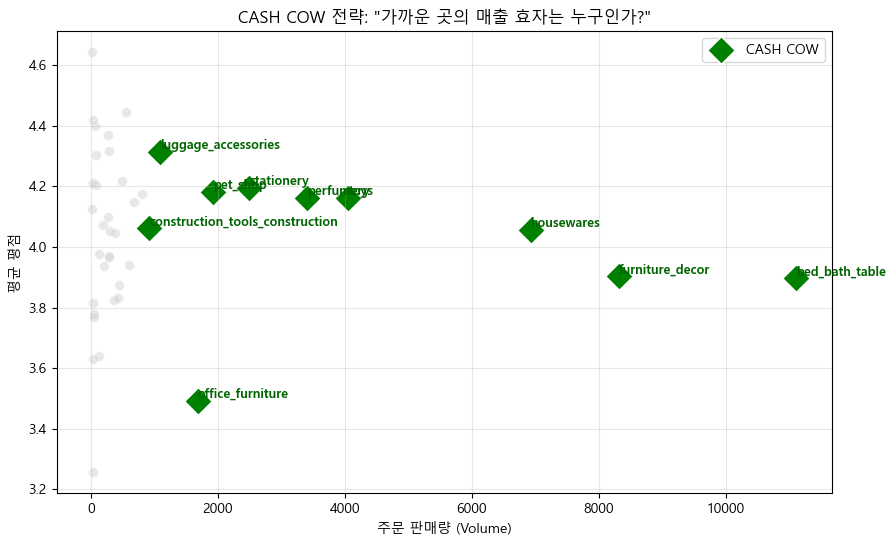

In [18]:
#시각화 (이름표 필수)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=short_dist_items, x='Volume', y='Score', color='lightgray', s=50, alpha=0.5)
sns.scatterplot(data=cash_cow_top10, x='Volume', y='Score', color='green', s=200, marker='D', label='CASH COW')

for i in range(len(cash_cow_top10)):
    row = cash_cow_top10.iloc[i]
    plt.text(row['Volume'], row['Score']+0.01, row['Category'], fontsize=9, fontweight='bold', color='darkgreen')

plt.title('CASH COW 전략: "가까운 곳의 매출 효자는 누구인가?"')
plt.xlabel('주문 판매량 (Volume)')
plt.ylabel('평균 평점')
plt.grid(True, alpha=0.3)
plt.show()